## ANN for classification, example 2, red wine quality classification

In [1]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

# encoders
from sklearn.preprocessing import LabelEncoder

# classification metrics
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [2]:
# load the data
df = pd.read_csv("winequality-red.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# check the distribution, completely even distribution (uniform)
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [5]:
df['quality'] = df['quality'].replace({3: 4, 8: 7})
df['quality'].value_counts().sort_index()

quality
4     63
5    681
6    638
7    217
Name: count, dtype: int64

<Axes: >

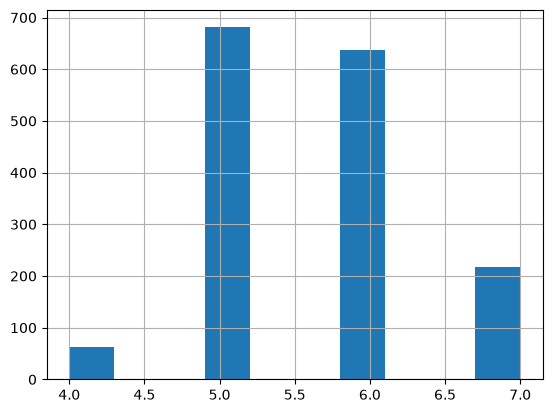

In [6]:
# still not a good distribution , but let's try a neural network with this 
df['quality'].hist()

## X/y -split

**NOTE! Due to cross entropy, we have to modify the y-variable further! See details below**

In [7]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("quality", axis=1)

# have only the target variable here (dependent variable)
y_temp = df['quality']

# since we are doing classification, we have to process our target values with an encoder
# and convert them into a categorical TensorFlow/Keras -format
le = LabelEncoder()
y_enc = le.fit_transform(y_temp)

# convert the label into matrix form
y = tf.keras.utils.to_categorical(y_enc)

# save the categories into a helper list for later purposes
categories = list(le.classes_)

# let's force the list of categories into string
categories = list(map(str, categories))
categories



['4', '5', '6', '7']

In [8]:
# compare y_temp and y in order to see how they are different
# y

### train/test/validation -split

In [9]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

### Create the neural network structure

**NOTE: you can use all the same callback features as in regression: ModelCheckpoint, EarlyStop, ReduceLRONPlateau, Dropout-layers etc...**

In [10]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape

# output layer in classification depends on the amounts of
# unique output options in the target variable
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(8, activation="relu"),
        layers.Dense(len(categories), activation="softmax")
    ]
)

# select the optimizer and loss function
# for classification, we use categorical crossentropy this time for loss-function
# we also wish to measure the accuracy of our model in the metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 11)             │            44 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408 (1.59 KB)

 Trainable params: 386 (1.51 KB)

 Non-trainable params: 22 (88.00 B)

**Train the next**

In [11]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=300, validation_data=(X_val, y_val))

Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3167 - loss: 5.4625 - val_accuracy: 0.3786 - val_loss: 5.1910
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3792 - loss: 4.7948 - val_accuracy: 0.4214 - val_loss: 4.4943
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4273 - loss: 4.2429 - val_accuracy: 0.4464 - val_loss: 3.9693
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4678 - loss: 3.7549 - val_accuracy: 0.4821 - val_loss: 3.5430
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5072 - loss: 3.3162 - val_accuracy: 0.5143 - val_loss: 3.1546
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5448 - loss: 2.9285 - val_accuracy: 0.5429 - val_loss: 2.7918
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5419 - loss: 2.5731 - val_accuracy: 0.5464 - val_loss: 2.4542
Epoch 8/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5582 - loss: 2.2535 - val_accuracy: 0.5679 - v

### Error and performance metrics

<Axes: >

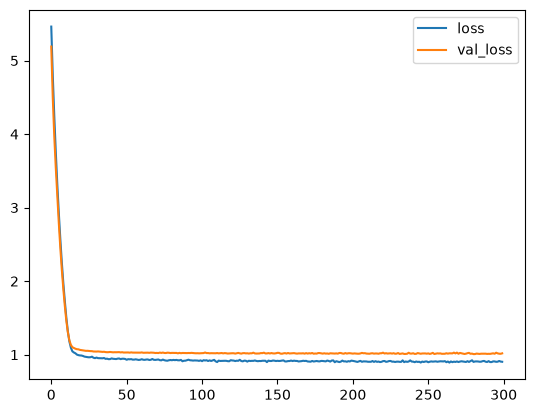

In [12]:
loss_df = pd.DataFrame(model.history.history)
loss_df[['loss', 'val_loss']].plot()

# the model seems to learn fairly well according to loos
# not overfitting, but there's a slight room for improvement

<Axes: >

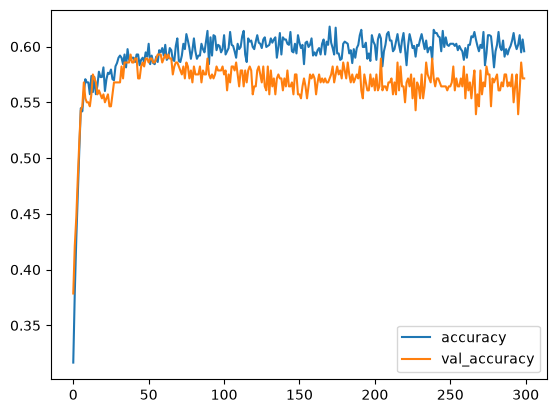

In [13]:
# validation accuracy is fairly high (which is the result from the validation dataset)
# training accuracy is a bit low, but val_accuracy is usually more important to be maximized
# training accuracy being low can imply there's toom for improvement still in the neural network
loss_df[['accuracy', 'val_accuracy']].plot()

In [14]:
# compare the final model loss/evaluation values
# the values should match roughly
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

# in classification we compare the loss and accuracy values

Test data evaluation:
[0.984562337398529, 0.6142857074737549]

Train data evaluation:
[0.8910557627677917, 0.6082772016525269]


In [15]:
# get predictions and convert with argmax() to get the categories
# instead of RAW probabilites
test_predictions = model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)

# convert also y-test values with argmax
y_test = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<Axes: >

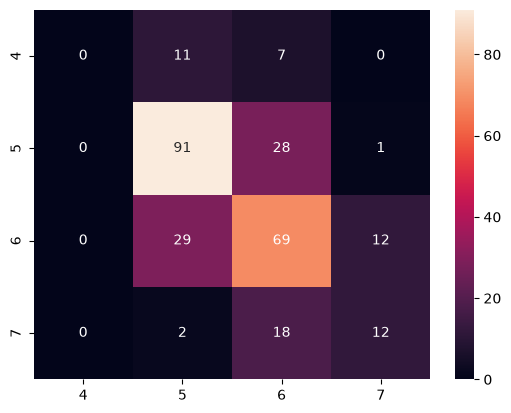

In [16]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g',
            xticklabels=categories, yticklabels=categories)

In [17]:
# print the classification report based on true values and predictions
print(classification_report(y_test, test_predictions, target_names=categories))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00        18
           5       0.68      0.76      0.72       120
           6       0.57      0.63      0.59       110
           7       0.48      0.38      0.42        32

    accuracy                           0.61       280
   macro avg       0.43      0.44      0.43       280
weighted avg       0.57      0.61      0.59       280


Model overall accuracy: 61.43%


c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

In [18]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary classification, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multi category classification , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# get ROC-AUC -score
roc_auc_score(y, model.predict(X), multi_class="ovr")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step


0.7622672272222992

### Try the model in practice with new data

In [19]:
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

In [20]:
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [28]:
# let's try with some imaginary data
# modify this as needed regarding your own dataset

tester_row = {
    'fixed acidity': 7.4, 
    'volatile acidity': 0.27, 
    'citric acid': 0, 
    'residual sugar': 2.0,
    'chlorides': 0.1, 
    'free sulfur dioxide': 12, 
    'total sulfur dioxide': 36, 
    'density': 0.99,
    'pH': 3.5, 
    'sulphates': 0.6, 
    'alcohol': 13.9
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]
result_text = categories[np.argmax(result)]

# switch to decimal representation 
np.set_printoptions(precision=9, suppress=True)

# 0 cheapest, 3 most expensive
print(f"Predicted price range: {result_text}")
print()
print("Probabilities by class:")
print(categories)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted price range: 7

Probabilities by class:
['4', '5', '6', '7']
[0.001782218 0.014000485 0.26607263  0.7181447  ]
